## Tarea S11.01. Visualización de Datos con Python y Power BI

### *Andrey Ismagilov*
### *Fecha 02/02/2025*

In [132]:
import mysql.connector
import pandas as pd
import math
from datetime import datetime, date, time, timedelta
import seaborn as sns

### **Nivel 1**

### **Ejercicio 1.** 
### Conecta Python con MySQL Workbench y carga los datos de tu base de datos de Sprint 4 para utilizarlos en todos los ejercicios.

In [133]:
config = {
  'user': 'root',
  'password': '206205',
  'host': '127.0.0.1',
  'database': 'transactions_sp4',
  'raise_on_warnings': True
}

try:
    connection = mysql.connector.connect(** config)
    cursor = connection.cursor()
    
    # Cargamos los datos de la tabla "transaction"
    sql_select_query_transaction = "select * from transaction"
    cursor.execute(sql_select_query_transaction)
    rec_transactions = cursor.fetchall()
    print("Total number of rows in table transaction: ", cursor.rowcount)

    df_transaction = pd.DataFrame(rec_transactions, 
        columns=['id', 'credit_card_id', 'company_id', 'timestamp', 'amount', 'declined', 'product_ids', 'user_id', 'lat', 'longitude'])
    
    # Cargamos los datos de la tabla "data_user"
    sql_select_query_data_user = "select * from data_user"
    cursor.execute(sql_select_query_data_user)
    rec_data_user = cursor.fetchall()
    print("Total number of rows in table data_user: ", cursor.rowcount)

    df_data_user = pd.DataFrame(rec_data_user, 
        columns=['id', 'name', 'surname', 'phone', 'email', 'birth_date', 'country', 'city', 'postal_code', 'address'])
    
    # Cargamos los datos de la tabla "companies"
    sql_select_query_companies = "select * from companies"
    cursor.execute(sql_select_query_companies)
    rec_companies = cursor.fetchall()
    print("Total number of rows in table companies: ", cursor.rowcount)

    df_companies = pd.DataFrame(rec_companies, 
        columns=['id', 'company_name', 'phone', 'email', 'country', 'website'])
    
    # Cargamos los datos de la tabla "credit_cards"
    sql_select_query_credit_cards = "select * from credit_cards"
    cursor.execute(sql_select_query_credit_cards)
    rec_credit_cards = cursor.fetchall()
    print("Total number of rows in table credit_cards: ", cursor.rowcount)

    df_credit_cards = pd.DataFrame(rec_credit_cards, 
        columns=['id', 'user_id', 'iban', 'pan', 'pin', 'cvv', 'track1', 'track2', 'expiring_date'])
    
    # Cargamos los datos de la tabla "products"
    sql_select_query_products = "select * from products"
    cursor.execute(sql_select_query_products)
    rec_products = cursor.fetchall()
    print("Total number of rows in table products: ", cursor.rowcount)

    df_products = pd.DataFrame(rec_products, 
        columns=['id', 'product_name', 'price', 'colour', 'weight', 'warehouse_id'])
    
    # Cargamos los datos de la tabla "transaction_products"
    sql_select_query_transaction_products = "select * from transaction_products"
    cursor.execute(sql_select_query_transaction_products)
    rec_transaction_products = cursor.fetchall()
    print("Total number of rows in table transaction_products: ", cursor.rowcount)

    df_transaction_products = pd.DataFrame(rec_transaction_products, 
        columns=['transaction_id', 'product_id'])
    
    # Cargamos los datos de la tabla "credit_card_status"
    sql_select_query_credit_card_status = "select * from credit_card_status"
    cursor.execute(sql_select_query_credit_card_status)
    rec_credit_card_status = cursor.fetchall()
    print("Total number of rows in table credit_card_status: ", cursor.rowcount)

    df_credit_card_status = pd.DataFrame(rec_credit_card_status, 
        columns=['cc_id', 'status'])

except mysql.connector.Error as e:
    print("Error reading data from MySQL table", e)
finally:
    if connection.is_connected():
        connection.close()
        cursor.close()
        print("MySQL connection is closed")

Total number of rows in table transaction:  100000
Total number of rows in table data_user:  5000
Total number of rows in table companies:  100
Total number of rows in table credit_cards:  5000
Total number of rows in table products:  100
Total number of rows in table transaction_products:  253391
Total number of rows in table credit_card_status:  5000
MySQL connection is closed


In [134]:
df_transaction.head(3)

,id,credit_card_id,company_id,timestamp,amount,declined,product_ids,user_id,lat,longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.1999,1.43554
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,"66, 69, 87",438,41.5972,12.22180
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,"30, 11, 16, 81",2118,29.7573,-95.37960


In [135]:
df_data_user.head(3)

,id,name,surname,phone,email,birth_date,country,city,postal_code,address
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,"Nov 17, 1985",United States,New York,10001,348-7818 Sagittis St.
1,2,Garrett,Mcconnell,(718) 257-2412,integer.vitae.nibh@protonmail.org,"Aug 23, 1992",United States,Philadelphia,19101,903 Sit Ave
2,3,Ciaran,Harrison,(522) 598-1365,interdum.feugiat@aol.org,"Apr 29, 1998",United States,Houston,77001,736-2063 Tellus St.


In [136]:
df_companies.head(3)

,id,company_name,phone,email,country,website
0,b-2222,Ac Fermentum Incorporated,06 85 56 52 33,donec.porttitor.tellus@yahoo.net,Germany,https://instagram.com/site\r
1,b-2226,Magna A Neque Industries,04 14 44 64 62,risus.donec.nibh@icloud.org,Australia,https://whatsapp.com/group/9\r
2,b-2230,Fusce Corp.,08 14 97 58 85,risus@protonmail.edu,United States,https://pinterest.com/sub/cars\r


In [137]:
df_credit_cards.head(3)

,id,user_id,iban,pan,pin,cvv,track1,track2,expiring_date
0,CcS-4857,276,XX4857591835292505850771,2314242385113924,1819,467,%B2314242385113924^LWCBUDLWCBUD^22060000000000...,%B2314242385113924=2410101518363164?,09/27/25
1,CcS-4858,277,XX8581768137002436094025,6582720299715533,3964,817,%B6582720299715533^TIQMVITIQMVI^24040000000000...,%B6582720299715533=2411101104546272?,12/28/28
2,CcS-4859,278,XX7826930491423553609370,8861684536289642,4983,277,%B8861684536289642^COFBGDCOFBGD^28020000000000...,%B8861684536289642=2502101761665371?,11/26/26


In [138]:
df_products.head(3)

,id,product_name,price,colour,weight,warehouse_id
0,1,Direwolf Stannis,$161.11,#7c7c7c,1,WH-4
1,2,Tarly Stark,$9.24,#919191,2,WH-3
2,3,duel tourney Lannister,$171.13,#d8d8d8,1.5,WH-2


In [139]:
df_transaction_products.head(3)

,transaction_id,product_id
0,001A60EA-DC9C-4E5A-9460-6628B100E7E1,1
1,0032F0BB-BBE6-4AA5-B5EE-EEAD533C0C48,1
2,00342381-503D-422D-85AB-F2D4FFAAD4C7,1


In [140]:
df_credit_card_status.head(3)

,cc_id,status
0,CcS-4857,Active
1,CcS-4858,Active
2,CcS-4859,Active


### **Ejercicio 2.** 

#### Per a cada ítem, crea una visualització adequada segons les variables especificades. Interpreta els resultats segons les teves dades.

##### 2.1. Una variable numérica.

Creamos el histograma de la variable **amount** de la tabla **transaction**.

In [141]:
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              100000 non-null  object        
 1   credit_card_id  100000 non-null  object        
 2   company_id      100000 non-null  object        
 3   timestamp       100000 non-null  datetime64[ns]
 4   amount          100000 non-null  object        
 5   declined        100000 non-null  int64         
 6   product_ids     100000 non-null  object        
 7   user_id         100000 non-null  int64         
 8   lat             100000 non-null  float64       
 9   longitude       100000 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 7.6+ MB


In [142]:
df_transaction.shape

(100000, 10)

In [143]:
df_transaction = df_transaction.set_index('id')

In [144]:
df_transaction['amount'] = pd.to_numeric(df_transaction['amount'])

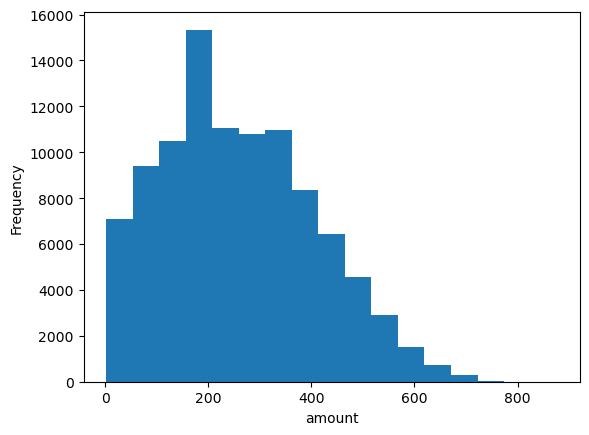

In [145]:
num_intervalos = int( round(1 + 3.22 * math.log10(df_transaction.shape[0])) )
df_transaction['amount'].plot.hist(bins=num_intervalos, xlabel='amount');
#df.plot(kind='hist', bins='sturges', edgecolor='black')

Vemos que los importes de ventas estan concentrados entre 150 y 300 dollares.

#### 2.2. Dos variables numéricas.

Creamos el scatterplot de la variable **price** de producto y el **número de ventas** de producto.

In [146]:
df_products.set_index('id', inplace=True)
df_products.head(3)

,product_name,price,colour,weight,warehouse_id
id,,,,,
1,Direwolf Stannis,$161.11,#7c7c7c,1,WH-4
2,Tarly Stark,$9.24,#919191,2,WH-3
3,duel tourney Lannister,$171.13,#d8d8d8,1.5,WH-2


In [147]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 1 to 100
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_name  100 non-null    object
 1   price         100 non-null    object
 2   colour        100 non-null    object
 3   weight        100 non-null    object
 4   warehouse_id  100 non-null    object
dtypes: object(5)
memory usage: 4.7+ KB


Convertimos la variable "price" a numerica.

In [148]:
df_products.price = df_products.price.str.replace('$', '').astype(float)

In [149]:
df_products_precio = pd.merge(df_transaction_products.product_id.value_counts(), df_products, left_on='product_id', right_index=True)

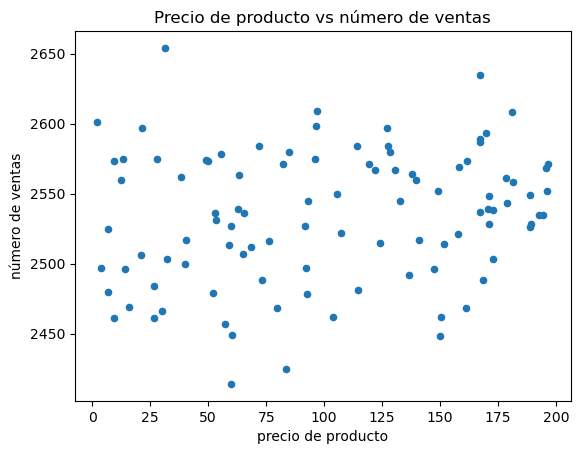

In [150]:
df_products_precio.plot.scatter(x='price', y='count', xlabel='precio de producto', ylabel='número de ventas', 
                                                                                title = 'Precio de producto vs número de ventas');

Usando la libreria **seaborn** agregando la recta de regresión lineal.

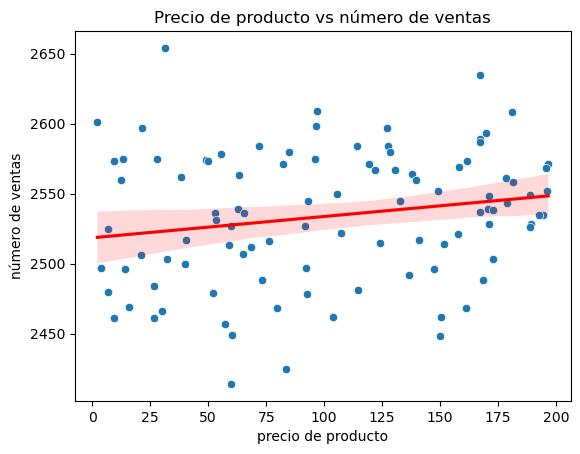

In [ ]:
import matplotlib.pyplot as plt

sns.scatterplot(data = df_products_precio, x = 'price', y = 'count')

# Agregamos la recta de regresión lineal
sns.regplot(data=df_products_precio, x='price', y='count', scatter=False, color='red')

# Configuración de etiquetas y título
plt.xlabel('precio de producto')
plt.ylabel('número de ventas')
plt.title('Precio de producto vs número de ventas')

plt.show()

In [152]:
df_products_precio[['count', 'price']].corr()

,count,price
count,1.00000,0.19234
price,0.19234,1.00000


No observamos ninguna correlación entre las variables.

#### 2.3. Una variable categórica.

Creamos el gráfico de barras de número de transacciones por pais de usuarios.

In [153]:
df_transaction_data_user = pd.merge(df_transaction, df_data_user, left_on = 'user_id', right_on = 'id')

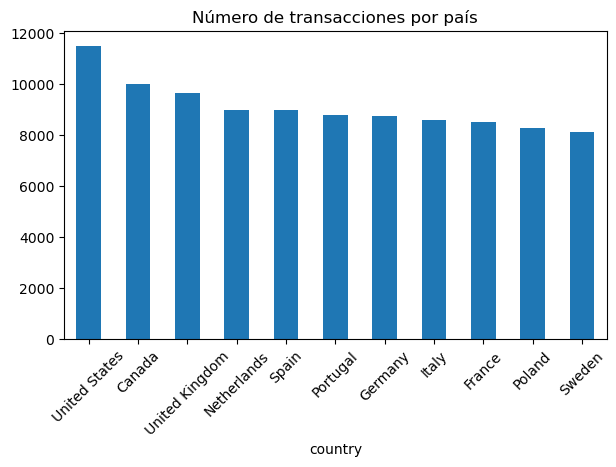

In [154]:
df_transaction_por_pais = df_transaction_data_user['country'].value_counts().sort_values(ascending=False)
df_transaction_por_pais.plot.bar(x='country',title='Número de transacciones por país', figsize=(7, 4), rot=45);

Top 3 paises son United States, Canada, United Kingdom y Nettherlands.

#### 2.3. Una variable categórica y una numérica.

Creamos el gráfico de boxplot de la variable amount por países de empresas.

In [155]:
df_transaction_companies = pd.merge(df_transaction, df_companies, left_on = 'company_id', right_on = 'id')

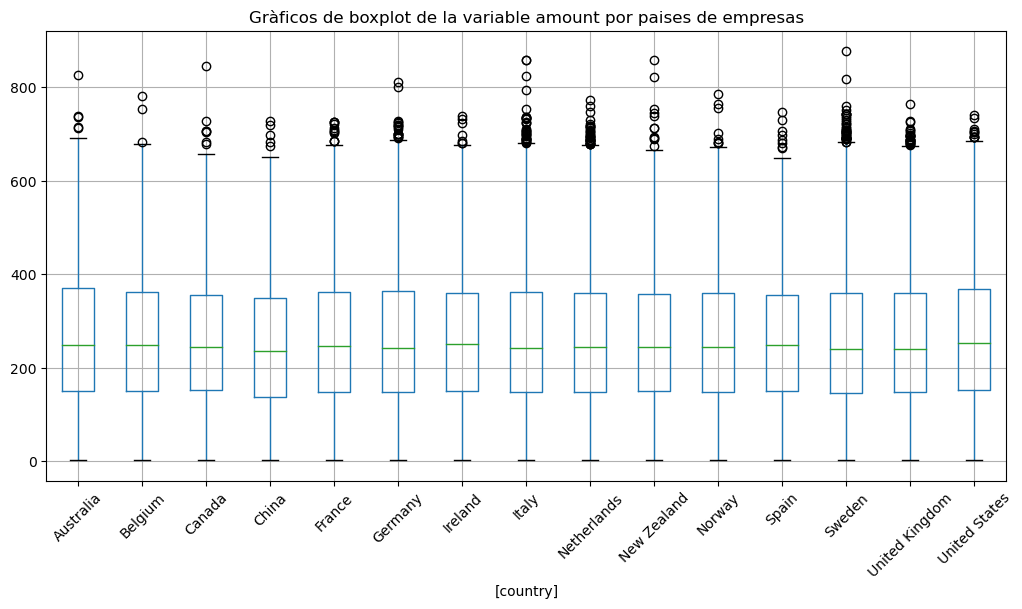

In [156]:
df_transaction_companies[['country', 'amount']].boxplot(by='country', figsize=(12, 6), rot=45)
plt.title('Gràficos de boxplot de la variable amount por paises de empresas')
plt.suptitle('')
plt.show()

# 'Gràficos boxplot de la variable amount por paises de empresas'

Observamos que las medianas de **amount** por paises son similares. 

Se nota que por ejemplo Italy, Netherlands, Sweden y United Kingdom representan más outliers que otros paises.

#### 2.4. Dos variables categóricas.

Creamos el gráfico de barras del número de transacciones por país de top 5 empresas de últimos 5 años.

In [157]:
df_transaction_companies.head(3)

,credit_card_id,company_id,timestamp,amount,declined,product_ids,user_id,lat,longitude,id,company_name,phone,email,country,website
0,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,"16, 26, 97, 87",4713,46.1999,1.435540,b-2458,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r
1,CcS-7604,b-2458,2018-08-01 11:03:20,171.13,0,3,3023,54.9751,-3.404650,b-2458,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r
2,CcS-5054,b-2458,2015-12-12 20:57:12,126.89,0,"100, 30, 70",473,39.4695,-0.386054,b-2458,Eget Tincidunt Dui Institute,05 35 93 32 44,eget.laoreet@hotmail.org,Netherlands,https://wikipedia.org/user/110\r


In [158]:
df_transaction_companies['año'] = df_transaction_companies['timestamp'].dt.year
df_año_pais = pd.crosstab(df_transaction_companies['año'], df_transaction_companies['country'], margins=True).tail(6)
df_año_pais = df_año_pais.T.sort_values(by='All')
df_año_pais.drop(index='All', columns='All' ,inplace=True)
df_año_pais = df_año_pais.tail(5).T
df_año_pais

country,Germany,Italy,United Kingdom,Netherlands,Sweden
año,,,,,
2020,1444,1339,1401,1543,1622
2021,1567,1396,1416,1429,1675
2022,1481,1314,1345,1516,1645
2023,1268,1349,1396,1468,1654
2024,1261,1417,1365,1575,1587


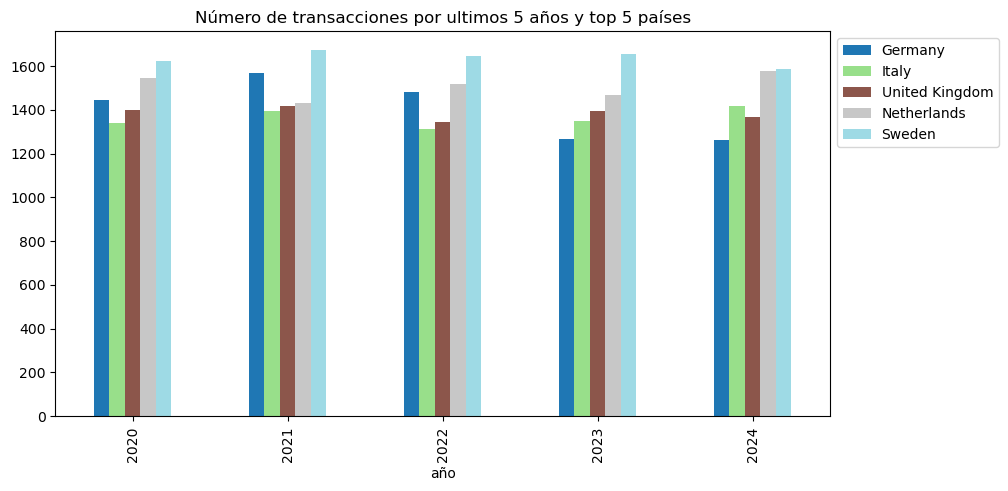

In [159]:
df_año_pais.plot.bar(title='Número de transacciones por ultimos 5 años y top 5 países', colormap='tab20', figsize=(10,5)).legend(bbox_to_anchor=(1.0, 1.0));

Observamos que Sweden tiene más ventas que otros paises. También se ve la disminución de las ventas en Germany.

#### 2.5. Tres variables combinadas.

Creamos el gráfico de barras apiladas de suma de ventas por año y país.

In [160]:
df_transaction_companies['año'] = df_transaction_companies['timestamp'].dt.year
df_año_pais = pd.crosstab(df_transaction_companies['año'], df_transaction_companies['country'], 
                                df_transaction_companies['amount'], aggfunc='sum', margins=True).tail(6)
df_año_pais = df_año_pais.T.sort_values(by='All')
df_año_pais.drop(index='All', columns='All' ,inplace=True)
df_año_pais = df_año_pais.tail(10).T
df_año_pais

country,Ireland,Norway,Belgium,United States,France,Germany,Italy,United Kingdom,Netherlands,Sweden
año,,,,,,,,,,
2020,71870.39,74854.14,89254.38,98798.70,126410.36,369065.84,345866.98,369173.57,391419.61,426681.30
2021,75808.87,78643.71,90412.34,101987.00,120136.99,412694.02,354119.52,355225.23,374157.78,425971.05
2022,57261.01,82719.11,96002.81,109750.60,126333.25,420451.68,341266.51,350596.07,393737.82,421360.75
2023,69833.92,75575.27,99462.91,117240.35,123799.87,331281.08,343685.93,358159.20,370644.07,422308.43
2024,64444.73,81377.94,94484.57,110814.31,128610.87,324512.99,371878.45,347968.88,410104.70,410635.20


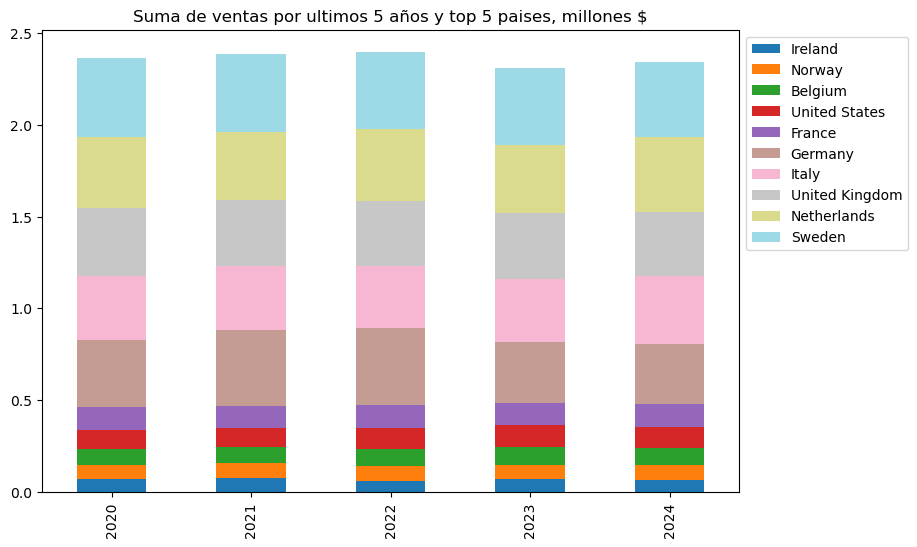

In [161]:
df_año_pais_mil = df_año_pais / 1000000
df_año_pais_mil.plot.bar(stacked=True, colormap='tab20', xlabel='', figsize=(9,6),
                            title='Suma de ventas por ultimos 5 años y top 5 paises, millones $').legend(bbox_to_anchor=(1.0, 1.0));

#### 2.6. Crea un Pairplot.

In [162]:
df_transaction.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 00043A49-2949-494B-A5DD-A5BAE3BB19DD to FFFD31D6-9495-47CE-B54A-7DB8E1CC274B
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   credit_card_id  100000 non-null  object        
 1   company_id      100000 non-null  object        
 2   timestamp       100000 non-null  datetime64[ns]
 3   amount          100000 non-null  float64       
 4   declined        100000 non-null  int64         
 5   product_ids     100000 non-null  object        
 6   user_id         100000 non-null  int64         
 7   lat             100000 non-null  float64       
 8   longitude       100000 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 7.6+ MB


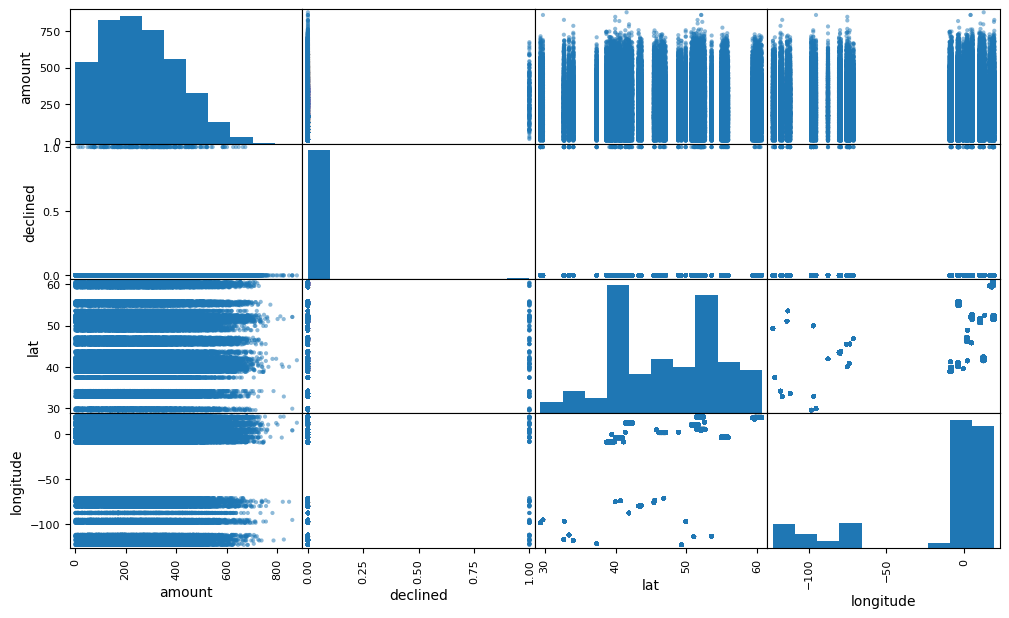

In [163]:
pd.plotting.scatter_matrix(df_transaction[['amount', 'declined', 'lat', 'longitude']], figsize=(12,7));

En el histograma de la variable **declined** podemos ver que hay muy pocas las transacciones rechazadas comparado con las no rechazadas.

Ademas en la histogramas de las variables **lat** y **longitude** onservamos que los datos estan concentrados en ciertas zonas.

Esto significa que los usuarios en estas ubicaciónes geográficas (países) hacen más compras que en otras.

### **Nivel 2**

### **Ejercicio 1.** 

### Representa la correlació d'algunes variables i interpreta els resultats segons les teves dades.

In [164]:
df_transaction[['amount', 'declined', 'lat', 'longitude']].corr()

,amount,declined,lat,longitude
amount,1.000000,0.013513,-0.008176,-0.005780
declined,0.013513,1.000000,-0.017668,-0.028616
lat,-0.008176,-0.017668,1.000000,0.504625
longitude,-0.005780,-0.028616,0.504625,1.000000


<Axes: >

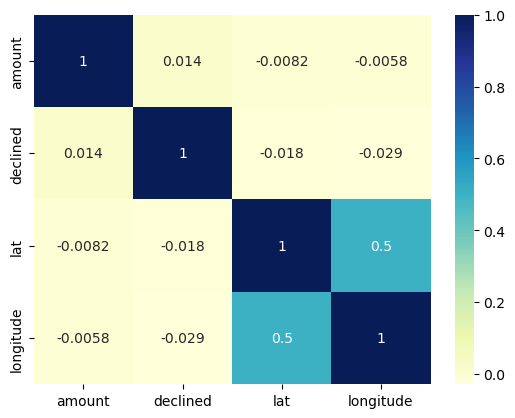

In [165]:
sns.heatmap(df_transaction[['amount', 'declined', 'lat', 'longitude']].corr(), cmap='YlGnBu', annot=True)

Se ve que no hay correlaciones fuertes entre las variables numericas de la tabla **transaction**. 

Solo la variable **lat** y la **longitude** tienen el coeficiente de Pearson 0.5, que tampoco es alto.

### **Ejercicio 2.** 

### Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

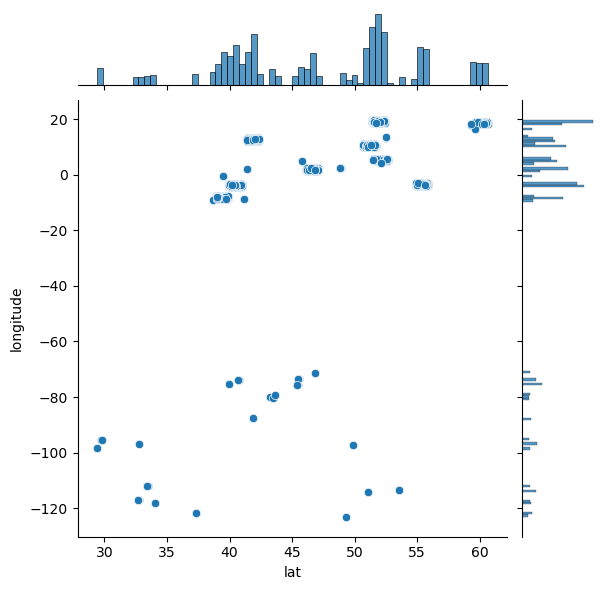

In [166]:
sns.jointplot(x='lat', y='longitude', data=df_transaction)

En este gráfico podemos ver claramente las zonas donde estan consentrados los usuarios que hacen las compras.

### **Nivel 3**

### **Ejercicio 1.** 

#### Transfiere todas las visualizaciones del Nivel 1 a Power BI utilizando scripts de Python.